In [1]:
import pandas as pd
import numpy as np
import os
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

# 模型输入
输入数据应为日频，模型采用对数收益率；月末调仓，从月末的后一个交易日开始计算收益率；

考虑到各资产存在可交易日期不同的情况，部分资产缺少收益率的日期中，将收益率中的NA填为0。

In [2]:
# 资产数据文件
target_docu = "ALL_ASSETS.xlsx"
events_docu = r"Final_Results_20260223_235650\events_all.xlsx"
trades_docu = r"Final_Results_20260223_235650\trades_OOS.xlsx"

# 使用到的数据的时间范围
start_date = "2006-11-01"
end_date = "2026-01-31"

# 风险平价模型参数设置
LOOKBACK_MONTHS = 6          # 用过去6个月日收益估计协方差
ANNUAL_DAYS = 252
RF_ANNUAL = 0.015              # 年化无风险利率（先设0；你之后可换成曲线/序列）
LONG_ONLY = True
STRATEGY_START = "2022-12-31" #策略构建与回测时间起点，此处和国泰君安研报保持一致，以方便策略结果的比较。原则上其实06年11月开始有数据，07年5月就可以回测了

# 调仓日模式：月末决策换仓："month"；风险预算变化决策换仓："rw"
mode = "rw"

# 数据准备（日频对数收益率，缺失值以0填充）

In [3]:
df = pd.read_excel(target_docu)
df["Trddt"] = pd.to_datetime(df["Trddt"])
df["Clsidx"] = pd.to_numeric(df["Clsidx"], errors="coerce")
df = df.dropna(subset=["Indexcd", "Trddt", "Clsidx"])

# 看数据的时间范围
df["Trddt"].min(), df["Trddt"].max()

(Timestamp('2006-11-20 00:00:00'), Timestamp('2026-01-26 00:00:00'))

In [4]:
# 限制数据范围
df = df[(df["Trddt"] >= start_date) & (df["Trddt"] <= end_date)]

# 排序
df = df.sort_values(["Indexcd", "Trddt"]).reset_index(drop=True)

# 计算日对数收益率
df["log_ret"] = df.groupby("Indexcd")["Clsidx"].transform(
    lambda x: np.log(x) - np.log(x.shift(1))
)

df = df.dropna(subset=["log_ret"]) #这里还没有用日期为列，所以应该只去掉了各资产数据的第一天，无法往前减数字所以没有log return的情况
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28459 entries, 1 to 28464
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Indexcd  28459 non-null  object        
 1   Trddt    28459 non-null  datetime64[ns]
 2   Clsidx   28459 non-null  float64       
 3   log_ret  28459 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 1.1+ MB


In [5]:
ret_sub = (df
              .pivot(index="Trddt", columns="Indexcd", values="log_ret")
              .sort_index()
             )

ret_sub.head()

Indexcd,CBA02001,COMEX,HS300,HSI,NHCI,SP500
Trddt,,,,,,
2006-11-21,-0.000100,0.011205,0.011911,0.002827,-0.007057,0.001648
2006-11-22,-0.000702,0.000796,0.007280,0.012676,0.012713,0.002335
2006-11-23,-0.001103,NaN,0.006677,0.000754,-0.004726,NaN
2006-11-24,0.000803,0.000000,0.001021,-0.000261,0.005442,-0.003662
2006-11-27,-0.001606,0.018439,0.009257,-0.002927,0.015383,-0.013648


In [6]:
#ret_sub = ret_sub.fillna(0.0)
#ret_sub.tail()

In [7]:
# 计算各资产之间的协方差和相关系数，由于数据为日频收益率，协方差数值会偏小
cov_matrix = ret_sub.cov()
corr_matrix = ret_sub.corr()

# --- 打印查看 ---
print("=== 协方差矩阵 (Covariance) ===")
print(cov_matrix.head())
print("\n=== 相关系数矩阵 (Correlation) ===")
print(corr_matrix.head())

=== 协方差矩阵 (Covariance) ===
Indexcd       CBA02001         COMEX         HS300           HSI  \
Indexcd                                                            
CBA02001  1.040980e-06 -5.759079e-08 -4.669902e-07 -8.310752e-07   
COMEX    -5.759079e-08  1.252355e-04  8.080230e-06  9.297161e-06   
HS300    -4.669902e-07  8.080230e-06  2.599539e-04  1.308976e-04   
HSI      -8.310752e-07  9.297161e-06  1.308976e-04  2.372841e-04   
NHCI     -6.698232e-07  1.293164e-05  5.438254e-05  5.810157e-05   

Indexcd           NHCI         SP500  
Indexcd                               
CBA02001 -6.698232e-07 -4.674302e-07  
COMEX     1.293164e-05  4.880068e-06  
HS300     5.438254e-05  2.186243e-05  
HSI       5.810157e-05  4.260036e-05  
NHCI      9.397113e-05  9.656165e-06  

=== 相关系数矩阵 (Correlation) ===
Indexcd   CBA02001     COMEX     HS300       HSI      NHCI     SP500
Indexcd                                                             
CBA02001  1.000000 -0.004999 -0.028119 -0.052945 -0.067

In [8]:
assets = ret_sub.columns.tolist()
n = len(assets)

# ============================================================
# ✅ 两套“决策日 rebalance_dates”：
#   A) 月末决策换仓：每个月最后一个交易日作为“决策日”，下个交易日生效
#   B) rw_df 日期决策换仓：当 rw_df 发生变化的交易日作为“决策日”，下个交易日生效
# ============================================================

# ---- A) 月末决策日（每个月最后一个交易日）----
rebalance_dates_mth = ret_sub.groupby(pd.Grouper(freq="ME")).apply(lambda x: x.index.max())
rebalance_dates_mth = rebalance_dates_mth[rebalance_dates_mth >= STRATEGY_START]

# 防止调仓日是有数据的最后一天引起报错（因为需要下一个交易日作为生效日）
rebalance_dates_mth = rebalance_dates_mth[rebalance_dates_mth < ret_sub.index.max()]

# 兼容旧变量名（如果后面还有代码引用）
rebalance_dates = rebalance_dates_mth.copy()

rebalance_dates[:]

Trddt
2022-12-31   2022-12-31
2023-01-31   2023-01-31
2023-02-28   2023-02-28
2023-03-31   2023-03-31
2023-04-30   2023-04-28
2023-05-31   2023-05-31
2023-06-30   2023-06-30
2023-07-31   2023-07-31
2023-08-31   2023-08-31
2023-09-30   2023-09-29
2023-10-31   2023-10-31
2023-11-30   2023-11-30
2023-12-31   2023-12-31
2024-01-31   2024-01-31
2024-02-29   2024-02-29
2024-03-31   2024-03-29
2024-04-30   2024-04-30
2024-05-31   2024-05-31
2024-06-30   2024-06-28
2024-07-31   2024-07-31
2024-08-31   2024-08-30
2024-09-30   2024-09-30
2024-10-31   2024-10-31
2024-11-30   2024-11-29
2024-12-31   2024-12-31
2025-01-31   2025-01-31
2025-02-28   2025-02-28
2025-03-31   2025-03-31
2025-04-30   2025-04-30
2025-05-31   2025-05-30
2025-06-30   2025-06-30
2025-07-31   2025-07-31
2025-08-31   2025-08-29
2025-09-30   2025-09-30
2025-10-31   2025-10-31
2025-11-30   2025-11-28
2025-12-31   2025-12-31
Freq: ME, dtype: datetime64[ns]

# 风险预算模型
相较于风险平价模型，风险预算模型允许使用者自行设定为第i类资产设定的风险权重（风险贡献在组合风险中的占比）

## 生成动态风险预算

In [9]:
events_list = pd.read_excel(events_docu)
trades_list = pd.read_excel(trades_docu)

# ret_sub index 是交易日（DatetimeIndex）
idx_dates = pd.to_datetime(ret_sub.index)
ret_sub.index = idx_dates  # 保证是 datetime

# trades_list 日期转 datetime
trades_list["日期"] = pd.to_datetime(trades_list["日期"])

In [10]:
valid_events = set(events_list["事件名称"].astype(str).str.strip().dropna().unique())
trades_f = trades_list.loc[
    trades_list["事件名称"].astype(str).str.strip().isin(valid_events)
].copy()

In [11]:
side = trades_f["买卖"].astype(str).str.strip().str.upper()

trades_f["资产预算变化"] = np.select(
    [side.isin(["BUY", "买"]), side.isin(["SELL", "卖"])],
    [1, -1],
    default=0
).astype(int)

In [12]:
date_arr = idx_dates.values  # numpy datetime64 array
sig_arr = trades_f["日期"].values.astype("datetime64[ns]")

# 在交易日序列中的插入位置（第一个 >= sig_date 的位置）
pos = np.searchsorted(date_arr, sig_arr, side="left")

# 如果刚好命中交易日且希望“下一个交易日生效”，则 pos 命中后要 +1
# 判断命中：pos < len and date_arr[pos]==sig
hit = (pos < len(date_arr)) & (date_arr[pos] == sig_arr)

pos_effective = pos.copy()
pos_effective[hit] = pos_effective[hit] + 1  # 命中则下一个交易日
# 未命中：pos 已经是第一个 > sig 的位置（因为 side="left" 且不存在等于），符合“下一可交易日”

# 越界（>=len）说明没有可执行日
valid = pos_effective < len(date_arr)
trades_f = trades_f.loc[valid].copy()
pos_effective = pos_effective[valid]

trades_f["执行日期"] = pd.to_datetime(date_arr[pos_effective])

In [13]:
assets = [a for a in trades_f["被解释资产"].astype(str).unique() if a in ret_sub.columns]
assets = pd.Index(assets, name="asset")

# ✅ 新增：delta（按执行日期×资产汇总变化）
delta = (
    trades_f.assign(被解释资产=lambda x: x["被解释资产"].astype(str))
    .groupby(["执行日期", "被解释资产"])["资产预算变化"]
    .sum()
    .unstack("被解释资产")
    .reindex(index=ret_sub.index, columns=assets)
    .fillna(0.0)
)

# ✅ 新增：risk_budget_df
# 初始预算=1，然后每日累计
risk_budget_df = 1.0 + delta.cumsum()
# 资产数量（后续优化统一使用这个维度）
n = len(assets)


In [14]:
risk_budget_execute = risk_budget_df.clip(lower=0.0)
row_sum = risk_budget_execute.sum(axis=1)
rw_df = risk_budget_execute.div(row_sum.replace(0, np.nan), axis=0)

n_assets = len(assets)
rw_df = rw_df.fillna(1.0 / n_assets)

In [15]:
# ============================================================
# ✅ 生成 “rw_df 日期决策日”：只在预算发生变化时调仓
#   直觉：预算没变就不必频繁再优化；预算变了才需要重新求权重
# ============================================================

def _align_decision_dates_to_trade_dates(decision_dates: pd.Index, idx_dates: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """把“决策日”对齐到交易日（<= 决策日 的最近交易日），并去重排序"""
    decision_dates = pd.to_datetime(pd.Index(decision_dates))
    pos = idx_dates.searchsorted(decision_dates, side="right") - 1
    pos = pos[pos >= 0]
    trade_dates = pd.Index(idx_dates[pos]).drop_duplicates().sort_values()
    # 需要下一个交易日作为生效日，所以最后一天不能作为调仓日
    trade_dates = trade_dates[trade_dates < idx_dates.max()]
    return pd.DatetimeIndex(trade_dates)

# ---- B) rw_df 日期决策日：rw_df 发生变化的日期 ----
# 用 rw_df 的逐行变化检测（也可以理解为 delta 当天非 0）
rw_change_mask = rw_df.diff().abs().sum(axis=1).fillna(0.0) > 1e-12
rebalance_dates_rw = rw_df.index[rw_change_mask]
rebalance_dates_rw = rebalance_dates_rw[rebalance_dates_rw >= STRATEGY_START]
rebalance_dates_rw = rebalance_dates_rw[rebalance_dates_rw < ret_sub.index.max()]

# 两套“真实调仓日（交易日）”
idx_dates = ret_sub.index
reb_trade_dates_mth = _align_decision_dates_to_trade_dates(rebalance_dates_mth, idx_dates)
reb_trade_dates_rw  = _align_decision_dates_to_trade_dates(rebalance_dates_rw,  idx_dates)

print("月末决策换仓：决策日数 =", len(rebalance_dates_mth), "｜真实调仓(交易日)数 =", len(reb_trade_dates_mth))
print("rw_df变动换仓：决策日数 =", len(rebalance_dates_rw),  "｜真实调仓(交易日)数 =", len(reb_trade_dates_rw))

月末决策换仓：决策日数 = 37 ｜真实调仓(交易日)数 = 37
rw_df变动换仓：决策日数 = 320 ｜真实调仓(交易日)数 = 320


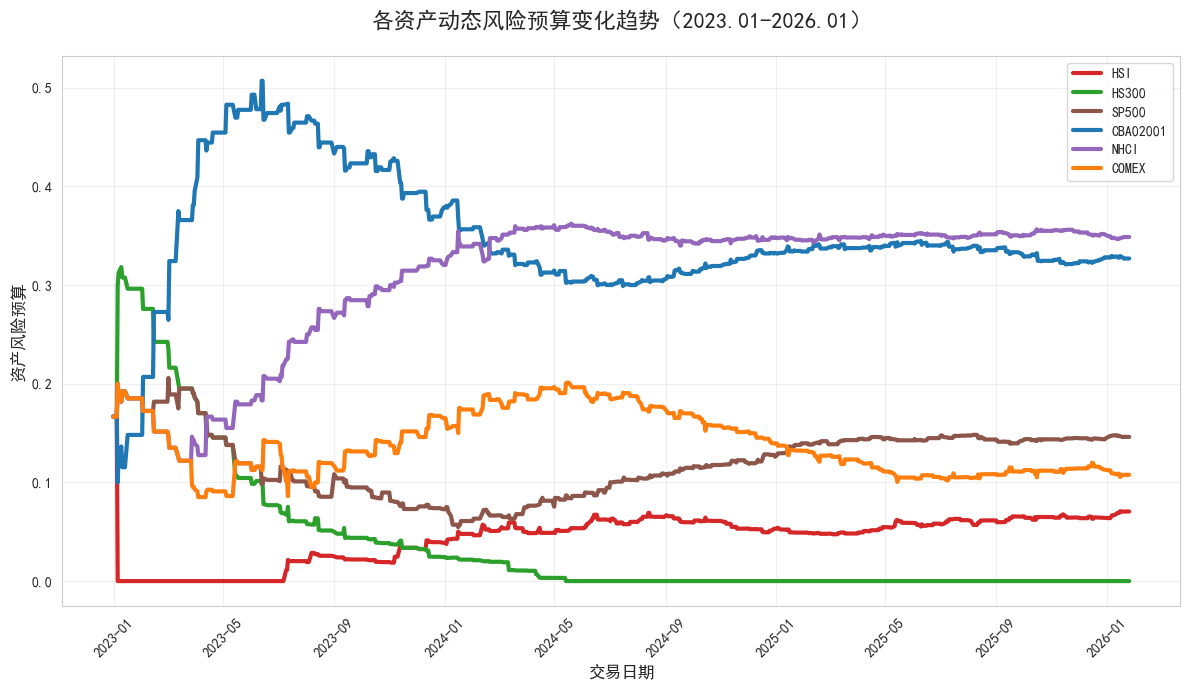

In [16]:
# 资产风险预算画图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建画布，设置合适大小（宽12，高7），适配多指标展示
plt.figure(figsize=(12, 7))

# 定义不同指标的样式（颜色+标记），方便区分
styles = {
    'CBA02001': {'color': '#1f77b4'},
    'COMEX': {'color': '#ff7f0e'},
    'HS300': {'color': '#2ca02c'},
    'HSI': {'color': '#d62728'},
    'NHCI': {'color': '#9467bd'},
    'SP500': {'color': '#8c564b'}
}

# 遍历所有指标列，逐列绘制折线图
for col in rw_df.columns:
    plt.plot(
        rw_df[rw_df.index >= STRATEGY_START].index,          # x轴：交易日期（索引）
        rw_df[rw_df.index >= STRATEGY_START][col],           # y轴：对应指标的数值
        label=col,            # 图例名称（列名）
        color=styles[col]['color'],  # 自定义颜色
        linewidth=3,          # 线条宽度
    )

# 添加图表美化元素
plt.title('各资产动态风险预算变化趋势（2023.01-2026.01）', fontsize=16, pad=20)  # 标题
plt.xlabel('交易日期', fontsize=12)                               # x轴标签
plt.ylabel('资产风险预算', fontsize=12)                               # y轴标签
plt.legend(loc='upper right', fontsize=10)                        # 图例（右上角）
plt.grid(True, alpha=0.3)                                        # 浅色网格线
plt.xticks(rotation=45)                                          # 日期旋转45度，避免重叠
plt.tight_layout()                                               # 自动调整布局，防止标签截断

# 显示图表（如需保存，取消下面注释）
plt.show()
# plt.savefig('各资产指标折线图.png', dpi=300, bbox_inches='tight')

## 执行动态风险预算

In [17]:
# 增加设置第i类资产的风险权重
rw = rw_df.copy()

In [18]:
def risk_budget_weights_from_window(
    ret_window: pd.DataFrame,
    rw: np.ndarray,
    w0: np.ndarray | None = None
) -> np.ndarray:

    Sigma = np.asarray(ret_window.cov().values)
    n_local = Sigma.shape[0]

    rw = np.asarray(rw, dtype=float).copy()
    rw = np.clip(rw, 0.0, None)
    if rw.size != n_local:
        rw = np.ones(n_local) / n_local
    else:
        rw = rw / rw.sum() if rw.sum() > 0 else np.ones(n_local) / n_local

    if w0 is None or np.asarray(w0).size != n_local:
        w0 = np.ones(n_local) / n_local
    else:
        w0 = np.asarray(w0, dtype=float).copy()
        w0 = np.clip(w0, 0.0, 1.0)
        w0 = w0 / w0.sum() if w0.sum() > 0 else np.ones(n_local) / n_local

    def obj_w(w):
        w = np.clip(w, 1e-12, 1.0)

        R = np.sqrt(float(w.T @ Sigma @ w))
        if R <= 0 or not np.isfinite(R):
            return 1e12

        MRC = (Sigma @ w) / R
        TRC = w * MRC

        target = rw * R
        return n_local * np.sum((TRC - target) ** 2)

    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0) for _ in range(n_local)] if LONG_ONLY else [(-1.0, 1.0) for _ in range(n_local)]

    res = minimize(
        obj_w, x0=w0, method="SLSQP",
        bounds=bounds, constraints=cons,
        options={"ftol": 1e-12, "maxiter": 2000, "disp": False}
    )

    w = res.x
    w = np.clip(w, 0.0, 1.0)
    w = w / w.sum()
    return w


def risk_parity_weights_from_window(
    ret_window: pd.DataFrame,
    w0: np.ndarray | None = None
) -> np.ndarray:
    """标准风险平价：各资产风险贡献相等（rw 全等）。"""
    n_local = ret_window.shape[1]
    rw_equal = np.ones(n_local) / n_local
    return risk_budget_weights_from_window(ret_window=ret_window, rw=rw_equal, w0=w0)


In [19]:
# ============================================================
# ✅ 风险预算 Risk Budget 策略：支持两套调仓日
#   - 月末决策换仓（reb_trade_dates_mth）
#   - rw_df 变动换仓（reb_trade_dates_rw）
#   决策日在 t_reb（交易日收盘后）计算权重，t_reb 的下一个交易日生效
#   考虑交易费用+滑点为单边千分之一
# ============================================================

# ============================================================
# ✅ 升级版：加入权重漂移追踪与真实交易费用
# ============================================================
FEE_RATE = 0.001  # 单边千分之一（包含佣金与滑点预估）

def run_risk_budget_strategy(reb_trade_dates: pd.DatetimeIndex, tag: str):
    weights_by_reb_local = []
    turnover_records = {}  # 新增：用于记录每次调仓的真实换手率
    port_log_ret_local = pd.Series(index=ret_sub.index, dtype="float64")

    # 新增：初始状态假设为全现金（0权重），第一次建仓也会产生费用
    w_drifted_prev = np.zeros(n)
    idx_dates = ret_sub.index

    for i, t_reb in enumerate(pd.DatetimeIndex(reb_trade_dates)):
        t_start = t_reb - pd.DateOffset(months=LOOKBACK_MONTHS)
        ret_window = ret_sub.loc[(idx_dates >= t_start) & (idx_dates <= t_reb), assets]

        if ret_window.shape[0] < 60:
            continue

        rw_t = rw_df.loc[t_reb].values
        rw_t = np.clip(rw_t, 0.0, None)
        rw_t = rw_t / rw_t.sum() if rw_t.sum() > 0 else np.ones(n) / n

        # 1. 算出目标权重
        w_t = risk_budget_weights_from_window(ret_window, rw=rw_t, w0=w_drifted_prev)
        weights_by_reb_local.append(pd.Series(w_t, index=assets, name=t_reb))

        # ==========================================
        # 🌟 交易费用与换手计算核心逻辑
        # ==========================================
        # 2. 计算调仓产生的真实单边换手率（新目标权重 - 漂移后的老权重）
        turnover = np.sum(np.abs(w_t - w_drifted_prev)) / 2.0
        turnover_records[t_reb] = turnover

        # 3. 计算本期调仓的资金留存系数 (扣除费用后的剩余资金比例)
        # 例如换手率20%，单边千一，总费率为 0.2 * 2 * 0.001 = 0.0004，留存 0.9996
        cost_factor = 1.0 - (turnover * 2 * FEE_RATE)
        # ==========================================

        pos = idx_dates.get_indexer([t_reb])[0]
        if pos == -1: continue
        if pos + 1 >= len(idx_dates): break
        t_effective = idx_dates[pos + 1]

        if i + 1 < len(reb_trade_dates):
            t_next_reb = pd.DatetimeIndex(reb_trade_dates)[i + 1]
            t_hold_end = min(t_next_reb, idx_dates.max())
        else:
            t_hold_end = idx_dates.max()

        hold_slice = ret_sub.loc[(idx_dates >= t_effective) & (idx_dates <= t_hold_end), assets]

        # 4. 资金曲线推演
        asset_nav = np.exp(hold_slice.cumsum())
        port_nav = asset_nav.values @ w_t
        port_nav_shifted = np.insert(port_nav[:-1], 0, 1.0)
        seg_log_ret = np.log(port_nav / port_nav_shifted)

        # 5. 第一天扣除交易摩擦导致的资金缩水（对数域直接相加）
        if len(seg_log_ret) > 0:
            seg_log_ret[0] += np.log(cost_factor)

        # 6. 计算本期末的自然漂移权重，供下一次循环使用
        end_asset_nav = asset_nav.iloc[-1].values
        w_drifted_end = w_t * end_asset_nav
        w_drifted_prev = w_drifted_end / np.sum(w_drifted_end) # 归一化成为漂移后的实际比例

        port_log_ret_local.loc[hold_slice.index] = seg_log_ret

    weights_df_local = pd.DataFrame(weights_by_reb_local)
    weights_df_local.index.name = "RebalanceDate"
    port_log_ret_local.name = f"port_log_ret_{tag}"

    # 🌟 将真实换手率一并返回
    turnover_series = pd.Series(turnover_records, name="ActualTurnover")
    return weights_df_local, port_log_ret_local, turnover_series

# ==========================================
# 后续运行调用方式也要相应微调，接收三个返回值：
# ==========================================
weights_df_mth, port_log_ret_mth, turnover_mth = run_risk_budget_strategy(reb_trade_dates_mth, tag="month")
weights_df_rw,  port_log_ret_rw,  turnover_rw  = run_risk_budget_strategy(reb_trade_dates_rw,  tag="rw")

In [20]:
# 分别计算累计收益
nav_mth = np.exp(port_log_ret_mth.fillna(0).cumsum())
nav_rw  = np.exp(port_log_ret_rw.fillna(0).cumsum())

# 打印真实的调仓次数
print(f"✅ 月末调仓策略：计算了 {len(weights_df_mth)} 次权重")
print(f"✅ 预算变动策略：计算了 {len(weights_df_rw)} 次权重")

# 验证结果是否真的“完全一样”
diff = (port_log_ret_mth - port_log_ret_rw).abs().sum()
print(f"⚠️ 两种策略收益率序列的总绝对误差: {diff:.6f}")

✅ 月末调仓策略：计算了 37 次权重
✅ 预算变动策略：计算了 320 次权重
⚠️ 两种策略收益率序列的总绝对误差: 0.024995


In [21]:
# 两套方案的收益序列（去掉空值）
port_log_ret_month = port_log_ret_mth.dropna()
port_log_ret_rw = port_log_ret_rw.dropna()

# 统一放入字典，后续用于对比输出
strategy_ret_map = {
    "month": port_log_ret_month,
    "rw": port_log_ret_rw,
}

# 按 mode 保留兼容变量（供后续导出模块使用）
if mode in ("month", "mth"):
    port_log_ret = port_log_ret_month.copy()
elif mode == "rw":
    port_log_ret = port_log_ret_rw.copy()
else:
    raise ValueError(f"mode 必须是 'month' 或 'rw'，当前为: {mode}")

# 计算并缓存两套方案净值
nav_map = {}
for k, series in strategy_ret_map.items():
    nav_k = np.exp(series.cumsum())
    nav_map[k] = nav_k / nav_k.iloc[0]

# 仍保留单变量 nav（兼容后续旧代码）
nav = nav_map["month" if mode in ("month", "mth") else "rw"]

# mode 对应方案的整体指标（兼容后续 save 输出）
running_max = nav.cummax()
drawdown = nav / running_max - 1.0
max_drawdown = drawdown.min()
mean_daily = port_log_ret.mean()
ann_return = np.exp(mean_daily * ANNUAL_DAYS) - 1
ann_vol = port_log_ret.std(ddof=1) * np.sqrt(ANNUAL_DAYS)
sharpe = (ann_return - RF_ANNUAL) / ann_vol if ann_vol > 0 else np.nan
calmar = ann_return / abs(max_drawdown) if max_drawdown < 0 else np.nan

metrics = pd.DataFrame([{
    "StartDate": port_log_ret.index.min(),
    "EndDate": port_log_ret.index.max(),
    "Obs": len(port_log_ret),
    "AnnReturn": ann_return,
    "AnnVolatility": ann_vol,
    "MaxDrawdown": max_drawdown,
    "Sharpe": sharpe,
    "Calmar": calmar
}])

metrics['AnnReturn'] = metrics['AnnReturn'].apply(lambda x: f"{x*100:.2f}%")
metrics['AnnVolatility'] = metrics['AnnVolatility'].apply(lambda x: f"{x*100:.2f}%")
metrics['MaxDrawdown'] = metrics['MaxDrawdown'].apply(lambda x: f"{x*100:.2f}%")
metrics['Sharpe'] = metrics['Sharpe'].apply(lambda x: f"{x:.2f}")
metrics['Calmar'] = metrics['Calmar'].apply(lambda x: f"{x:.2f}")



In [22]:
# 按 mode 选择用于导出模块的权重表（兼容旧逻辑）
if mode in ("month", "mth"):
    weights_df = weights_df_mth
elif mode == "rw":
    weights_df = weights_df_rw
else:
    raise ValueError(f"mode 必须是 'month' 或 'rw'，当前为: {mode}")

# 对比输出时使用两套权重
weights_df_map = {
    "month": weights_df_mth,
    "rw": weights_df_rw,
}



In [23]:
# ==========================================
# 修正后的绩效计算函数：直接接收真实换手率序列
# ==========================================

def calculate_metrics_updated(series, turnover_series, name_label=""):
    """
    series: 对数收益率序列
    turnover_series: run_risk_budget_strategy 返回的真实换手率
    """
    if len(series) < 5:
        return None

    start_date = series.index.min()
    end_date = series.index.max()
    years_frac = (end_date - start_date).days / 365.25

    # ✅ 修正：直接从策略记录中提取该时间段的换手率总和
    period_turnover = turnover_series.loc[(turnover_series.index >= start_date) &
                                          (turnover_series.index <= end_date)]
    total_turnover = period_turnover.sum()
    ann_turnover = total_turnover / years_frac if years_frac > 0 else total_turnover

    local_nav = np.exp(series.cumsum())
    local_nav = local_nav / local_nav.iloc[0]

    ann_return = np.exp(series.mean() * ANNUAL_DAYS) - 1
    ann_vol = series.std(ddof=1) * np.sqrt(ANNUAL_DAYS)

    max_drawdown = (local_nav / local_nav.cummax() - 1.0).min()
    sharpe = (ann_return - RF_ANNUAL) / ann_vol if ann_vol > 0 else np.nan
    calmar = ann_return / abs(max_drawdown) if max_drawdown < 0 else np.nan

    return {
        "Year": name_label,
        "StartDate": start_date.strftime('%Y-%m-%d'),
        "AnnReturn": ann_return,
        "AnnVolatility": ann_vol,
        "MaxDrawdown": max_drawdown,
        "AnnTurnover": ann_turnover, # 真实年化换手
        "Sharpe": sharpe,
        "Calmar": calmar
    }

def build_yearly_metrics_table_updated(port_series, turnover_series):
    # 将换手率索引标准化，确保能被 groupby 分组
    turnover_series.index = pd.to_datetime(turnover_series.index)

    metrics_list = []
    # 按年分组计算
    for year, group_data in port_series.groupby(port_series.index.year):
        m = calculate_metrics_updated(group_data, turnover_series, name_label=str(year))
        if m: metrics_list.append(m)

    # 全历史计算
    total_m = calculate_metrics_updated(port_series, turnover_series, name_label="All History")
    if total_m: metrics_list.append(total_m)

    df = pd.DataFrame(metrics_list).set_index("Year")

    fmt_df = df.copy()
    format_cols_pct = ['AnnReturn', 'AnnVolatility', 'MaxDrawdown', 'AnnTurnover']
    format_cols_num = ['Sharpe', 'Calmar']

    for col in format_cols_pct:
        if col in fmt_df.columns:
            fmt_df[col] = fmt_df[col].apply(lambda x: f"{x*100:.2f}%")
    for col in format_cols_num:
        if col in fmt_df.columns:
            fmt_df[col] = fmt_df[col].apply(lambda x: f"{x:.2f}")

    return fmt_df

# ====== 运行与展示 ======
# 1. 运行策略（使用您已经改好的 run_risk_budget_strategy）
weights_m, ret_m, turn_m = run_risk_budget_strategy(reb_trade_dates_mth, tag="month")
weights_r, ret_r, turn_r = run_risk_budget_strategy(reb_trade_dates_rw,  tag="rw")

# 2. 生成对比表（调用更新后的评估函数）
metrics_compare = {
    "month": build_yearly_metrics_table_updated(ret_m.dropna(), turn_m),
    "rw":    build_yearly_metrics_table_updated(ret_r.dropna(), turn_r)
}

print("=== 包含真实摩擦后的月度调仓表现 ===")
display(metrics_compare["month"])
print("=== 包含真实摩擦后的rw调仓表现 ===")
display(metrics_compare["rw"])

=== 包含真实摩擦后的月度调仓表现 ===


,StartDate,AnnReturn,AnnVolatility,MaxDrawdown,AnnTurnover,Sharpe,Calmar
Year,,,,,,,
2023,2023-01-03,7.81%,0.80%,-0.25%,16.91%,7.89,31.37
2024,2024-01-03,5.71%,0.87%,-0.30%,5.03%,4.84,18.94
2025,2025-01-02,3.07%,0.77%,-0.79%,11.07%,2.05,3.89
2026,2026-01-06,10.92%,0.80%,-0.05%,0.00%,11.81,230.20
All History,2023-01-03,5.62%,0.82%,-0.79%,10.66%,5.02,7.13


=== 包含真实摩擦后的rw调仓表现 ===


,StartDate,AnnReturn,AnnVolatility,MaxDrawdown,AnnTurnover,Sharpe,Calmar
Year,,,,,,,
2023,2023-01-06,7.56%,0.77%,-0.21%,24.84%,7.84,36.63
2024,2024-01-03,5.68%,0.88%,-0.30%,8.87%,4.78,18.88
2025,2025-01-02,2.97%,0.77%,-0.79%,13.92%,1.89,3.73
2026,2026-01-06,9.86%,0.72%,-0.05%,7.92%,11.67,218.80
All History,2023-01-06,5.46%,0.81%,-0.79%,15.50%,4.87,6.88


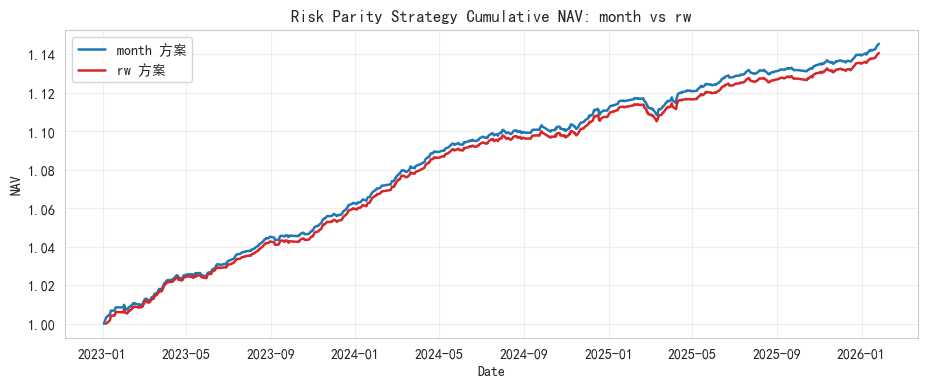

In [24]:
plt.figure(figsize=(11, 4))

for scheme, color, label in [
    ("month", "#1f77b4", "month 方案"),
    ("rw", "#d62728", "rw 方案"),
]:
    nav_curve = nav_map[scheme]
    plt.plot(nav_curve.index, nav_curve.values, label=label, linewidth=1.8, color=color)

plt.title("Risk Parity Strategy Cumulative NAV: month vs rw")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [25]:
for scheme in ["month", "rw"]:
    w = weights_df_map[scheme]
    print(f"\n===== {scheme} 方案：最后5次调仓权重分配 =====")
    print(w.tail(5))

    print("最后5次调仓权重分配和")
    print(w.sum(axis=1).tail(5))

    print("权重表中出现过的最小仓位")
    print(w.min().min())




===== month 方案：最后5次调仓权重分配 =====
asset               HSI     HS300     SP500  CBA02001      NHCI     COMEX
RebalanceDate                                                            
2025-08-29     0.004322  0.000564  0.010827  0.945963  0.028542  0.009782
2025-09-30     0.001770  0.000443  0.011001  0.949513  0.028421  0.008853
2025-10-31     0.007428  0.000000  0.017984  0.932468  0.030635  0.011485
2025-11-28     0.007327  0.000435  0.018364  0.932587  0.031851  0.009435
2025-12-31     0.003750  0.000300  0.017091  0.936659  0.033560  0.008641
最后5次调仓权重分配和
RebalanceDate
2025-08-29    1.0
2025-09-30    1.0
2025-10-31    1.0
2025-11-28    1.0
2025-12-31    1.0
dtype: float64
权重表中出现过的最小仓位
0.0

===== rw 方案：最后5次调仓权重分配 =====
asset               HSI         HS300     SP500  CBA02001      NHCI     COMEX
RebalanceDate                                                                
2026-01-13     0.005221  1.938023e-08  0.018162  0.940285  0.029381  0.006951
2026-01-14     0.005249  1.929531e-08

In [26]:
# =========================
# 同时导出 month + rw 两套方案（Excel 内 params sheet 会标注 scheme）
# =========================

export_paths = {}

# =========================
# 模型 1 的 params_snapshot（注意：这里不包含任何 leverage 参数）
# =========================
params_snapshot_model1 = {
    "data_file": "ALL_ASSETS.xlsx",
    "date_filter": {"start_date": start_date, "end_date": end_date},
    "strategy_start": STRATEGY_START,
    "lookback_months": LOOKBACK_MONTHS,
    "annual_days": ANNUAL_DAYS,
    "rf_annual": RF_ANNUAL,
    "long_only": LONG_ONLY,
    "min_window_days_guard": 60,
    "optimizer": {"method": "SLSQP", "ftol": 1e-12, "maxiter": 2000},
    "missing_value_rule": "ret_sub.fillna(0.0)",
}

def save_risk_parity_model1_two_files(
    output_dir: str,
    run_name: str,
    # ===== 必含（模型1一定有）=====
    params: dict,
    weights_df: pd.DataFrame,
    metrics_raw: pd.DataFrame,
    # ===== 可选（模型1里你现在也有，但允许你不传）=====
    ret_sub: pd.DataFrame | None = None,
    cov_matrix: pd.DataFrame | None = None,
    corr_matrix: pd.DataFrame | None = None,
    turnover: pd.Series | None = None,
    port_log_ret: pd.Series | None = None,
    nav: pd.Series | None = None,
):
    os.makedirs(output_dir, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    base = f"{run_name}_{ts}"

    # ---------- 1) params.json ----------
    params_path = os.path.join(output_dir, f"{base}_params.json")
    with open(params_path, "w", encoding="utf-8") as f:
        json.dump(params, f, ensure_ascii=False, indent=2, default=str)

    # ---------- 2) 统一日期粒度（去掉时分秒） ----------
    weights_df   = _dtindex_to_date(weights_df)     # RebalanceDate
    turnover     = _dtindex_to_date(turnover)       # RebalanceDate
    ret_sub      = _dtindex_to_date(ret_sub)        # Trddt
    port_log_ret = _dtindex_to_date(port_log_ret)   # Trddt
    nav          = _dtindex_to_date(nav)            # Trddt

    # 协方差/相关一般 index/columns 是资产名，不需要日期处理，但传进来就不动也没关系
    # metrics_raw 的 StartDate/EndDate 若是 Timestamp，也转成 date（更干净）
    if isinstance(metrics_raw, pd.DataFrame):
        metrics_raw = metrics_raw.copy()
        for c in ["StartDate", "EndDate"]:
            if c in metrics_raw.columns:
                metrics_raw[c] = pd.to_datetime(metrics_raw[c], errors="coerce").dt.date

    # ---------- 3) results.xlsx（只写模型1相关的 sheet） ----------
    xlsx_path = os.path.join(output_dir, f"{base}_results.xlsx")
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        # 必含
        _params_to_sheet_df(params).to_excel(writer, sheet_name="params", index=False)
        weights_df.to_excel(writer, sheet_name="weights", index=True)
        metrics_raw.to_excel(writer, sheet_name="metrics_raw", index=True)

        # 可选（存在就写）
        if ret_sub is not None:
            ret_sub.to_excel(writer, sheet_name="ret_sub_logret", index=True)
        if cov_matrix is not None:
            cov_matrix.to_excel(writer, sheet_name="cov_matrix", index=True)
        if corr_matrix is not None:
            corr_matrix.to_excel(writer, sheet_name="corr_matrix", index=True)
        if turnover is not None:
            turnover.rename("turnover").to_frame().to_excel(writer, sheet_name="turnover", index=True)
        if port_log_ret is not None:
            port_log_ret.rename("port_log_ret").to_frame().to_excel(writer, sheet_name="port_log_ret", index=True)
        if nav is not None:
            nav.rename("nav").to_frame().to_excel(writer, sheet_name="nav", index=True)

    print("✅ Model 1 saved (exactly 2 files, no leverage outputs):")
    print(" -", xlsx_path)
    print(" -", params_path)
    return xlsx_path, params_path


for scheme in ["month", "rw"]:
    # 1) 取该方案对应的对象
    weights_df_scheme = weights_df_map[scheme]
    port_log_ret_scheme = strategy_ret_map[scheme]
    nav_scheme = nav_map[scheme]
    metrics_scheme = metrics_compare[scheme]  # 这是一个 DataFrame

    # 2) 该方案 turnover（如果你要写进 Excel）
    turnover_scheme = weights_df_scheme.diff().abs().sum(axis=1) / 2.0

    # 3) params 增加标注（会进 params sheet / params.json）
    params_snapshot_model1_scheme = dict(params_snapshot_model1)  # 浅拷贝即可
    params_snapshot_model1_scheme["scheme"] = scheme  # ✅关键标注
    params_snapshot_model1_scheme["scheme_label"] = "calendar_month_rebalance" if scheme == "month" else "risk_budget_rebalance"

    # 4) 导出（run_name 里也带 scheme，文件名不会互相覆盖）
    xlsx_path, params_path = save_risk_parity_model1_two_files(
        output_dir="model_runs",
        run_name=f"risk_parity_model1_unlevered_{scheme}",
        params=params_snapshot_model1_scheme,
        weights_df=weights_df_scheme,
        metrics_raw=metrics_scheme,
        ret_sub=ret_sub,
        cov_matrix=cov_matrix,
        corr_matrix=corr_matrix,
        turnover=turnover_scheme,
        port_log_ret=port_log_ret_scheme,
        nav=nav_scheme,
    )

    export_paths[scheme] = {"xlsx": xlsx_path, "params": params_path}

print("✅ Export done:")
print(export_paths)

NameError: name '_dtindex_to_date' is not defined

## 加杠杆的风险平价模型

In [ ]:
# 输入
TARGET_VOL_LIST = [0.02, 0.03, 0.04, 0.05, 0.06]
MIN_LEVERAGE = 0.80
MAX_LEVERAGE = 2

In [ ]:
# ============================================================
# ✅ 有杠杆 Risk Parity（目标波动）策略：同样支持两套调仓日
#   决策日在 t_reb（交易日收盘后）算 w* 与预测波动率，
#   t_reb 的下一个交易日生效
# ============================================================

def run_leverage_strategy(reb_trade_dates: pd.DatetimeIndex, tag: str):
    # ===== 相对权重（sum=1）=====
    weights_lev_by_reb_local = []

    # ===== 每个 target 对应一条收益序列 =====
    port_log_ret_lev_dict_local = {
        f"target_{int(tv*100)}pct": pd.Series(index=ret_sub.index, dtype="float64")
        for tv in TARGET_VOL_LIST
    }

    # ===== 杠杆记录（调仓日）=====
    leverage_rec_local = []

    # 用上一期相对权重作为初值
    w_prev_lev_local = np.ones(n) / n

    idx_dates = ret_sub.index

    for i, t_reb in enumerate(pd.DatetimeIndex(reb_trade_dates)):
        # ① 协方差窗口
        t_start = t_reb - pd.DateOffset(months=LOOKBACK_MONTHS)
        ret_window = ret_sub.loc[(idx_dates >= t_start) & (idx_dates <= t_reb), assets]

        if ret_window.shape[0] < 60:
            continue

        # ② 风险平价相对权重 w*（sum=1）
        w_star = risk_parity_weights_from_window(ret_window, w0=w_prev_lev_local)
        weights_lev_by_reb_local.append(pd.Series(w_star, index=assets, name=t_reb))
        w_prev_lev_local = w_star

        # ③ 生效日 = 下一个交易日
        pos = idx_dates.get_indexer([t_reb])[0]
        if pos == -1:
            continue
        if pos + 1 >= len(idx_dates):
            break
        t_effective = idx_dates[pos + 1]

        # ④ 持有截止日：下一个“决策日（交易日）”当日收盘
        if i + 1 < len(reb_trade_dates):
            t_next_reb = pd.DatetimeIndex(reb_trade_dates)[i + 1]
            t_hold_end = min(t_next_reb, idx_dates.max())
        else:
            t_hold_end = idx_dates.max()

        hold_slice = ret_sub.loc[(idx_dates >= t_effective) & (idx_dates <= t_hold_end), assets]

        # ⑤ 预测波动率（年化）
        Sigma = ret_window.cov().values
        var_hat = float(w_star.T @ Sigma @ w_star)
        sigma_hat_annual = (
            np.sqrt(var_hat) * np.sqrt(ANNUAL_DAYS)
            if np.isfinite(var_hat) and var_hat > 0
            else np.nan
        )

        # 记录
        lev_row = {"RebalanceDate": t_reb, "sigma_hat_annual": sigma_hat_annual}

        asset_nav = np.exp(hold_slice.cumsum())

        # ⑥ 对每个 target vol 生成一条策略
        for tv in TARGET_VOL_LIST:
            key = f"target_{int(tv*100)}pct"

            if not np.isfinite(sigma_hat_annual) or sigma_hat_annual <= 0:
                lev_t = 1.0
            else:
                lev_t = tv / sigma_hat_annual
                lev_t = min(MAX_LEVERAGE, max(MIN_LEVERAGE, lev_t))

            lev_row[key] = lev_t

            # ============= 修改点：含杠杆及现金留存的资金推演 =============
            w_lev = lev_t * w_star
            port_nav = asset_nav.values @ w_lev + (1.0 - lev_t)
            port_nav_shifted = np.insert(port_nav[:-1], 0, 1.0)
            port_log_ret_lev_dict_local[key].loc[hold_slice.index] = np.log(port_nav / port_nav_shifted)

        leverage_rec_local.append(lev_row)

    weights_df_local = pd.DataFrame(weights_lev_by_reb_local)
    weights_df_local.index.name = "RebalanceDate"
    leverage_df_local = pd.DataFrame(leverage_rec_local).set_index("RebalanceDate")
    # 给收益序列命名
    for k, s in port_log_ret_lev_dict_local.items():
        s.name = f"{k}_logret_{tag}"
    return weights_df_local, leverage_df_local, port_log_ret_lev_dict_local

# ====== 运行两套 rebalance_dates ======
weights_lev_df_mth, leverage_df_mth, port_log_ret_lev_dict_mth = run_leverage_strategy(reb_trade_dates_mth, tag="mth")
weights_lev_df_rw,  leverage_df_rw,  port_log_ret_lev_dict_rw  = run_leverage_strategy(reb_trade_dates_rw,  tag="rw")

# 按 mode 选择杠杆策略输出（兼容 rf）
mode_norm = str(mode).strip().lower()
if mode_norm in ("month", "mth"):
    weights_lev_by_reb = [row for _, row in weights_lev_df_mth.iterrows()]
    port_log_ret_lev_dict = port_log_ret_lev_dict_mth
    leverage_rec = leverage_df_mth.reset_index().to_dict(orient="records")
elif mode_norm in ("rw", "rf"):
    weights_lev_by_reb = [row for _, row in weights_lev_df_rw.iterrows()]
    port_log_ret_lev_dict = port_log_ret_lev_dict_rw
    leverage_rec = leverage_df_rw.reset_index().to_dict(orient="records")
else:
    raise ValueError(f"mode 必须是 'month'、'rw' 或 'rf'，当前为: {mode}")

print("✅ 杠杆策略（月末）调仓次数 =", len(weights_lev_df_mth))
print("✅ 杠杆策略（rw_df变动）调仓次数 =", len(weights_lev_df_rw))

leverage_df_mth.head()

In [ ]:
# 分别计算 month 与 rw 两套杠杆策略的各 target NAV
nav_lev_dict_mth = {}
for k, s in port_log_ret_lev_dict_mth.items():
    s = s.dropna()
    if len(s) == 0:
        continue
    nav_k = np.exp(s.cumsum())
    nav_k = nav_k / nav_k.iloc[0]
    nav_lev_dict_mth[k] = nav_k

nav_lev_dict_rw = {}
for k, s in port_log_ret_lev_dict_rw.items():
    s = s.dropna()
    if len(s) == 0:
        continue
    nav_k = np.exp(s.cumsum())
    nav_k = nav_k / nav_k.iloc[0]
    nav_lev_dict_rw[k] = nav_k

# 兼容旧变量：按当前 mode 暴露 nav_lev_dict
if mode_norm in ("month", "mth"):
    nav_lev_dict = nav_lev_dict_mth
else:
    nav_lev_dict = nav_lev_dict_rw

In [ ]:
# 1) month 方案单独输出
plt.figure(figsize=(10, 4))
for k, nav in nav_lev_dict_mth.items():
    plt.plot(nav.index, nav.values, label=k)
plt.title("Levered Risk Parity NAV (month)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2) rw 方案单独输出
plt.figure(figsize=(10, 4))
for k, nav in nav_lev_dict_rw.items():
    plt.plot(nav.index, nav.values, label=k)
plt.title("Levered Risk Parity NAV (rw)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 3) month 与 rw 放在一张图里对比输出（按 target 对应配对）
plt.figure(figsize=(11, 4))
for k in sorted(set(nav_lev_dict_mth.keys()) & set(nav_lev_dict_rw.keys())):
    plt.plot(nav_lev_dict_mth[k].index, nav_lev_dict_mth[k].values, label=f"month-{k}", linewidth=1.8)
    plt.plot(nav_lev_dict_rw[k].index, nav_lev_dict_rw[k].values, label=f"rw-{k}", linewidth=1.5, linestyle="--")
plt.title("Levered Risk Parity NAV: month vs rw")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()

